## 1. Import Required Libraries

In [26]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans

# Machine Learning Models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 2. Upload and Load Dataset

In [27]:
df = pd.read_csv('/content/Cardiovascular_disease_prediction.csv', sep=';')

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


# 3. Dataset Overview

In [28]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

df.info()
df.describe()
df.isnull().sum()

Shape: (70000, 13)

Columns: Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


# 4. Data Preprocessing

In [29]:
# Convert age (days → years)
df['age'] = df['age'] / 365

# Remove ID column
df.drop('id', axis=1, inplace=True)

# Remove unrealistic blood pressure values
df = df[(df['ap_hi'] < 200) & (df['ap_hi'] > 50)]
df = df[(df['ap_lo'] < 150) & (df['ap_lo'] > 30)]

# Fill missing values
df.fillna(df.mean(), inplace=True)

df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0
1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1
2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1
3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1
4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0


# 5.Correlation Heatmap

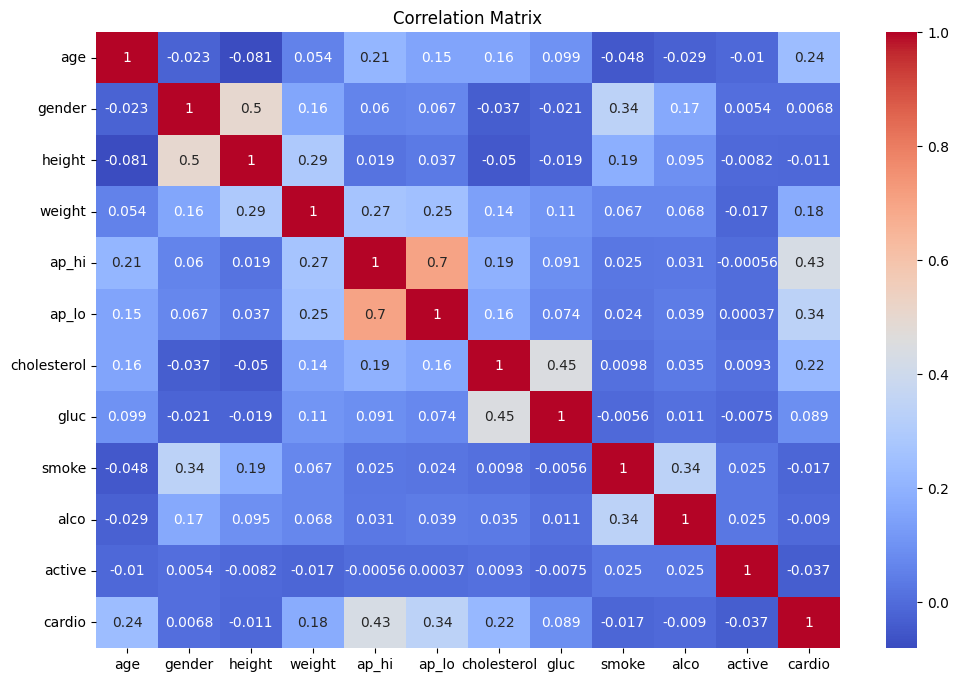

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# 6. Feature Scaling

In [31]:
X = df.drop('cardio', axis=1)
y = df['cardio']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7.Elbow Method

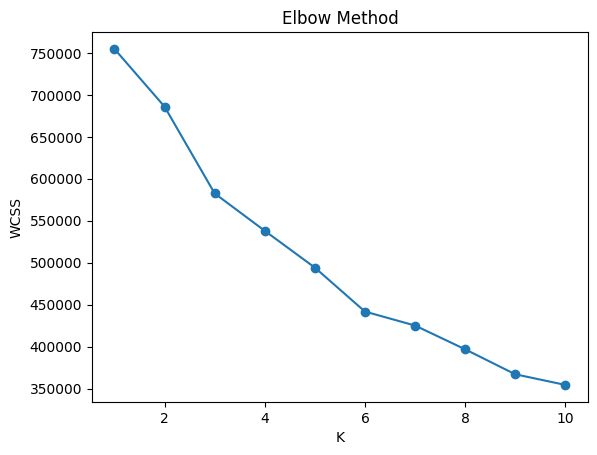

In [32]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

# 8. K-Means Clustering & PCA Visualization

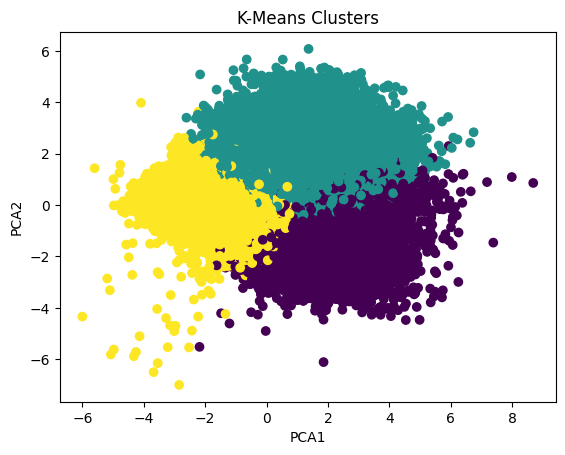

In [33]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)



pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

plt.figure()
plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'])
plt.title("K-Means Clusters")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()




# 9. Cluster Analysis

In [34]:
df.groupby('Cluster').mean()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,PCA1,PCA2
Cluster,,,,,,,,,,,,,,
0,56.324863,1.182028,162.093680,80.328185,141.275642,88.699934,2.152140,1.750494,0.026794,0.034167,0.807439,0.772219,1.388467,-1.426232
1,52.604738,1.973040,170.810649,77.542600,126.360245,81.549113,1.187612,1.104073,0.258008,0.127120,0.803643,0.473305,0.698220,1.492166
2,52.383404,1.030658,161.335860,69.017504,119.615723,77.675388,1.109549,1.058381,0.008559,0.015711,0.801412,0.377950,-1.086376,-0.281786


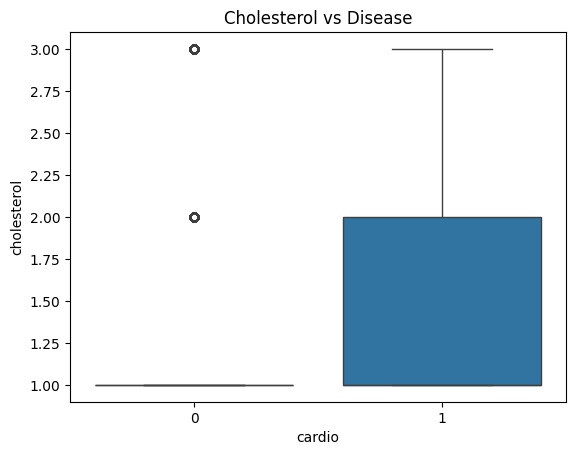

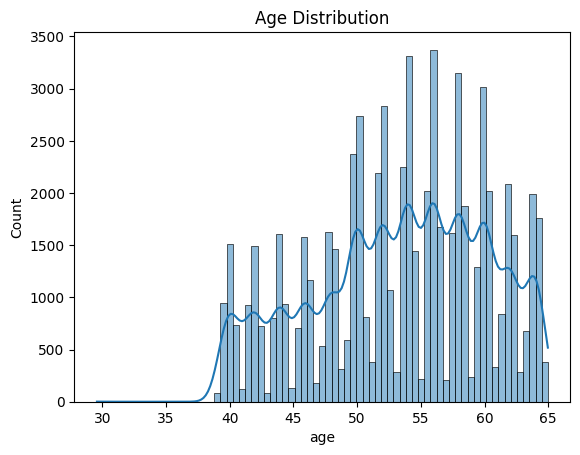

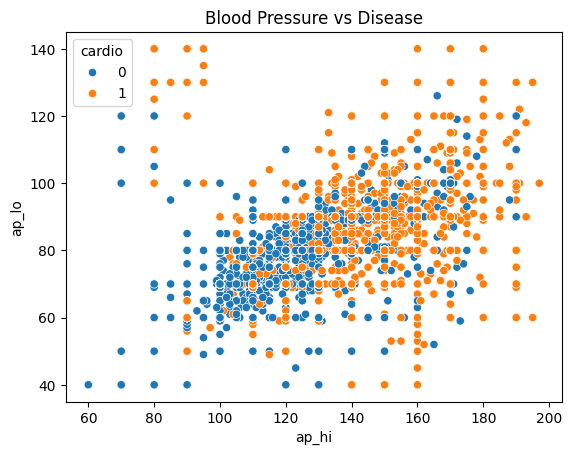

In [36]:
# Cholesterol vs Heart Disease
plt.figure()
sns.boxplot(x='cardio', y='cholesterol', data=df)
plt.title("Cholesterol vs Disease")
plt.show()

# Age Distribution
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Blood Pressure
plt.figure()
sns.scatterplot(x='ap_hi', y='ap_lo', hue='cardio', data=df)
plt.title("Blood Pressure vs Disease")
plt.show()

# 10. Train-Test Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [40]:
X_train


array([[-0.13037825, -0.73135496, -1.87798787, ..., -0.31034639,
        -0.23753354,  0.49465089],
       [-0.43378543, -0.73135496, -1.51124415, ..., -0.31034639,
        -0.23753354,  0.49465089],
       [ 0.20057456,  1.36732511, -0.04426927, ..., -0.31034639,
        -0.23753354,  0.49465089],
       ...,
       [ 0.65548278, -0.73135496,  0.07797864, ..., -0.31034639,
        -0.23753354,  0.49465089],
       [ 0.17910516, -0.73135496,  0.07797864, ..., -0.31034639,
        -0.23753354,  0.49465089],
       [-1.35818485,  1.36732511,  1.3004577 , ...,  3.22220601,
        -0.23753354,  0.49465089]])

In [41]:
X_test


array([[ 0.61294906,  1.36732511,  0.32247445, ..., -0.31034639,
        -0.23753354,  0.49465089],
       [-1.09893172, -0.73135496, -0.5332609 , ..., -0.31034639,
        -0.23753354,  0.49465089],
       [ 0.10132923, -0.73135496,  0.07797864, ..., -0.31034639,
        -0.23753354,  0.49465089],
       ...,
       [ 1.69816644,  1.36732511, -1.02225252, ..., -0.31034639,
        -0.23753354,  0.49465089],
       [ 0.14467311, -0.73135496, -0.04426927, ..., -0.31034639,
        -0.23753354,  0.49465089],
       [ 0.91757148, -0.73135496, -0.41101299, ..., -0.31034639,
        -0.23753354,  0.49465089]])

In [42]:
y_train


,cardio
5383,0
50613,0
6698,0
56264,1
59435,1
...,...
37950,0
6397,0
55991,1
874,0


In [43]:
y_test

,cardio
13814,0
42052,0
48686,1
35605,1
30798,1
...,...
58818,0
67051,1
2936,1
62492,1


# 11. All Models

In [44]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=50)
}

In [45]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.7214
Decision Tree: 0.6306
Random Forest: 0.7101


# 12.Accuracy Graph

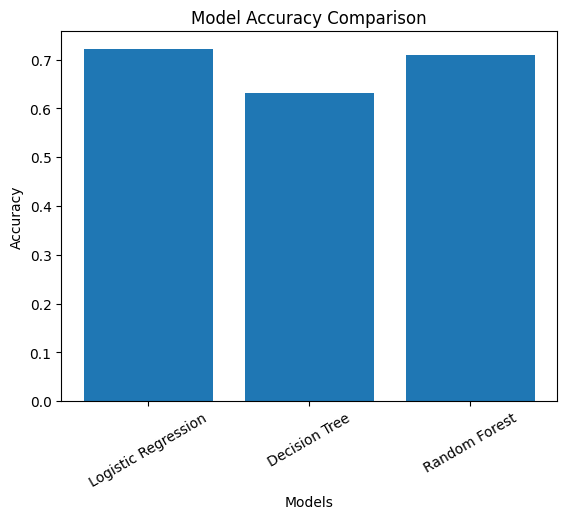

In [46]:
plt.figure()
plt.bar(results.keys(), results.values())

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)
plt.show()

# 13.Confusion Matrix

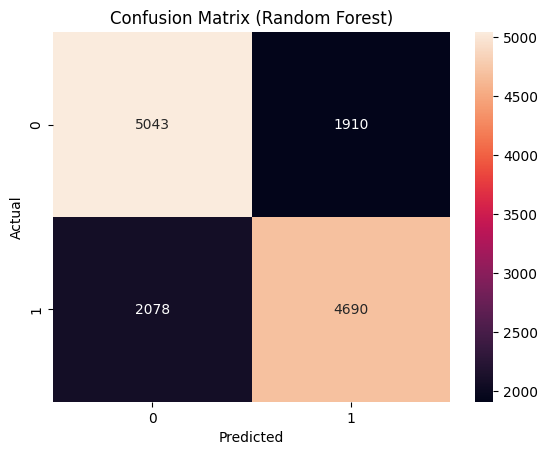

In [47]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()